# 02 - Classification Modeling

Target: `addiction_level`

This notebook trains and evaluates classification models, tunes the best one, and saves report artifacts.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "classification"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models" / "classification"
for p in [FIG_DIR, TABLE_DIR, OUTPUT_DIR / "predictions", OUTPUT_DIR / "tuning_results", MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[df["addiction_level"].notna()].copy()

def add_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["social_gaming_total_hours"] = out["social_media_hours"] + out["gaming_hours"]
    out["notifications_per_open"] = out["notifications_per_day"] / out["app_opens_per_day"].replace(0, 1)
    return out

df = add_features(df)
X = df.drop(columns=[c for c in ["transaction_id", "user_id", "addicted_label", "addiction_level"] if c in df.columns])
y = df["addiction_level"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

models = {
    "logistic_regression": LogisticRegression(max_iter=2000),
    "random_forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "svm_rbf": SVC(kernel="rbf"),
}

rows = []
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    rows.append({"model": name, "val_accuracy": accuracy_score(y_val, pred), "val_f1_weighted": f1_score(y_val, pred, average="weighted")})

results_df = pd.DataFrame(rows).sort_values("val_f1_weighted", ascending=False)
results_df.to_csv(TABLE_DIR / "classification_baseline_metrics.csv", index=False)
results_df

,model,val_accuracy,val_f1_weighted
1,random_forest,0.587824,0.586734
2,svm_rbf,0.546906,0.547316
0,logistic_regression,0.521956,0.509215


C:\Users\HP\AppData\Local\Temp\ipykernel_31360\2898161137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model", y="val_f1_weighted", palette="viridis")


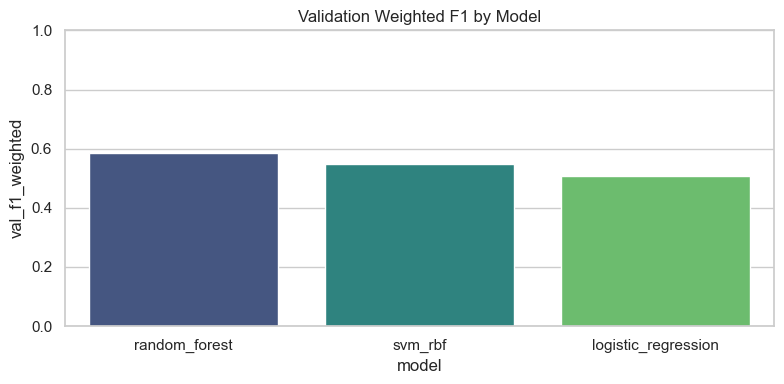

In [3]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="val_f1_weighted", palette="viridis")
plt.ylim(0, 1)
plt.title("Validation Weighted F1 by Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "validation_f1_model_comparison.png", dpi=300)
plt.show()

In [4]:
best_name = results_df.iloc[0]["model"]
if best_name == "random_forest":
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1)
    param_grid = {"model__n_estimators": [200, 300], "model__max_depth": [None, 10, 20], "model__min_samples_split": [2, 5]}
elif best_name == "logistic_regression":
    estimator = LogisticRegression(max_iter=3000)
    param_grid = {"model__C": [0.1, 1.0, 5.0], "model__solver": ["lbfgs", "saga"]}
else:
    estimator = SVC(kernel="rbf")
    param_grid = {"model__C": [0.5, 1.0, 2.0], "model__gamma": ["scale", "auto"]}

grid = GridSearchCV(
    estimator=Pipeline([("preprocessor", preprocessor), ("model", estimator)]),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)
final_model = grid.best_estimator_
final_model.fit(X_train_val, y_train_val)
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_weighted = f1_score(y_test, y_test_pred, average="weighted")
print(test_accuracy, test_f1_weighted)

0.5922233300099701 0.5846854325684627


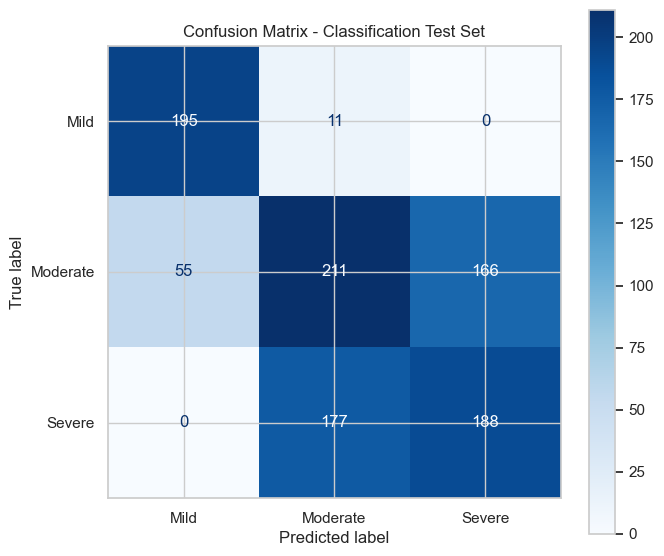

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap="Blues")
plt.title("Confusion Matrix - Classification Test Set")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_test.png", dpi=300)
plt.show()

In [6]:
pd.DataFrame([
    {"metric": "test_accuracy", "value": test_accuracy},
    {"metric": "test_f1_weighted", "value": test_f1_weighted},
    {"metric": "cv_best_f1_weighted", "value": grid.best_score_},
]).to_csv(TABLE_DIR / "classification_metrics.csv", index=False)

pd.DataFrame(grid.cv_results_).to_csv(OUTPUT_DIR / "tuning_results" / "classification_gridsearch_results.csv", index=False)
pd.DataFrame({"actual": y_test.values, "predicted": y_test_pred}).to_csv(OUTPUT_DIR / "predictions" / "classification_predictions.csv", index=False)
joblib.dump(final_model, MODEL_DIR / "best_classification_model.pkl")
print("Saved classification artifacts")

Saved classification artifacts
